<h1 style="font-size:42px; color:#062656; text-align:center;">
Titanic Survival Prediction
</h1>

In this notebook, I will be using the well known "Titanic" dataset to showcase skills in data exploration, data cleaning and feature engineering, modeling, and evaluation. 

The sinkning of the titanic in 1912 was an unthinkable event, given it was the "unsinkable ship". More than half the passangers and crew (1502 out of 2224) passed away after the ship collieded with an iceberg, took on water, split in half, and ultimately sank. 

**<span style="color:#00B894;">Data Overview</span>**

The data used in this notebook is the "Titanic Dataset" downloaded from the Kaggle website. The dataset contains passanger information such as age, sex, ticket class, and fare. The target variable is "Survived" indicating whether a passanger survived the Titantic disaster or not.  

In [1]:
# Common imports 

# Numpy and pandas are used for data manipulation and numerical operations 
import numpy as np
import pandas as pd 

# Matplotlib and seaborn are used for data visualization
import matplotlib.pyplot as plt 
import seaborn as sns 

# Sciki-learn is used for preprocessing, modeling, and evaluation
from sklearn. model_selection import train_test_split 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report 

# Settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [2]:
# Load the data 

train_df = pd.read_csv("C:\\Users\\alyss\\Downloads\\titanic\\train.csv")
test_df = pd.read_csv("C:\\Users\\alyss\\Downloads\\titanic\\test.csv")

# Not needed for modeling, but good to know
submission_df = pd.read_csv("C:\\Users\\alyss\\Downloads\\titanic\\gender_submission.csv") 

In [3]:
print("Train shape:", train_df.shape)
print("test shape:", test_df.shape)

train_df.head()

Train shape: (891, 12)
test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**<span style="color:#00B894;">Exploratory Data Analysis (EDA)</span>**

In this section, we explore the dataset to understand key patterns and relationships between features. The goal is to identify missing variables that may influence survival and detect any data quality issues such as missing values or imbalanced distributions. 

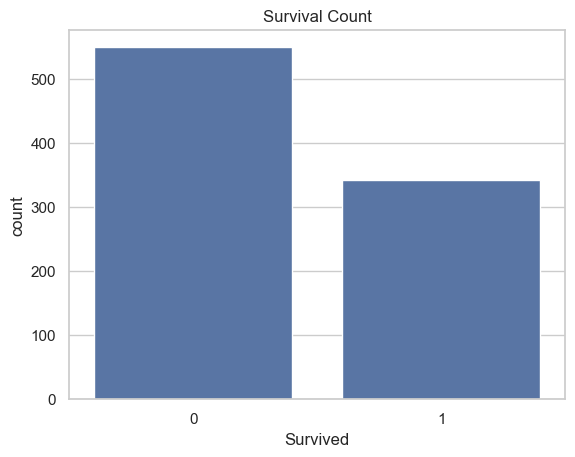

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [5]:
# Survival counts 
sns.countplot(data=train_df, x= 'Survived')
plt.title('Survival Count')
plt.show()

# Survival percentage 
train_df['Survived'].value_counts(normalize=True)

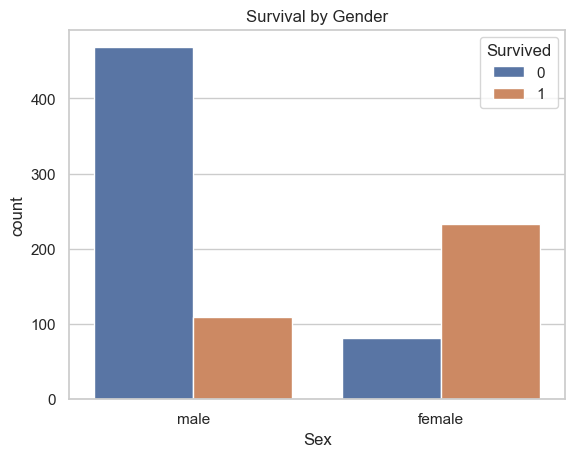

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [6]:
# Survival by gender 
sns.countplot(data=train_df, x='Sex', hue='Survived')
plt.title('Survival by Gender')
plt.show()

train_df.groupby('Sex')['Survived'].mean()

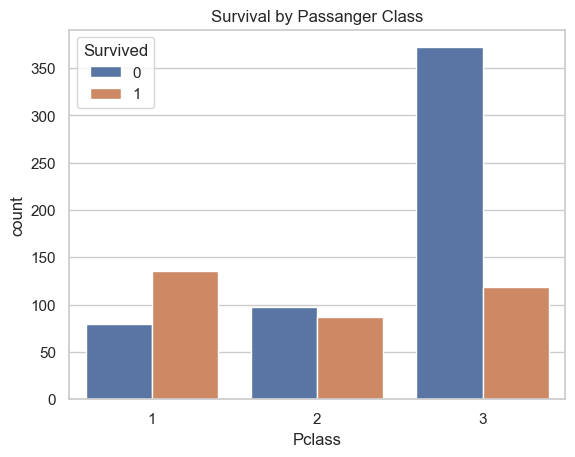

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [7]:
# Survival by passanger class 
sns.countplot(data = train_df, x='Pclass', hue='Survived')
plt.title('Survival by Passanger Class')
plt.show()

train_df.groupby('Pclass')['Survived'].mean()

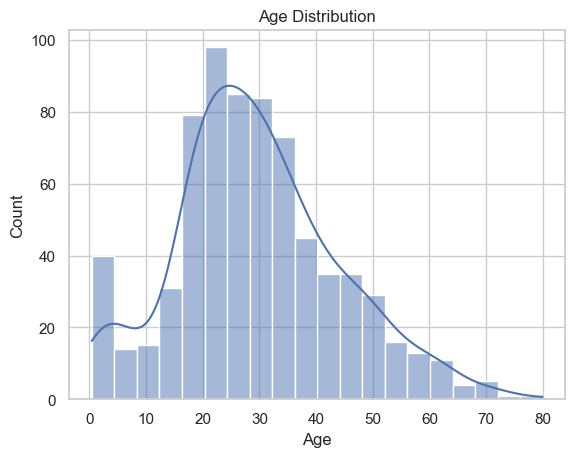

In [8]:
# Age Distribution 
sns.histplot(data=train_df, x='Age', kde=True)
plt.title('Age Distribution')
plt.show()

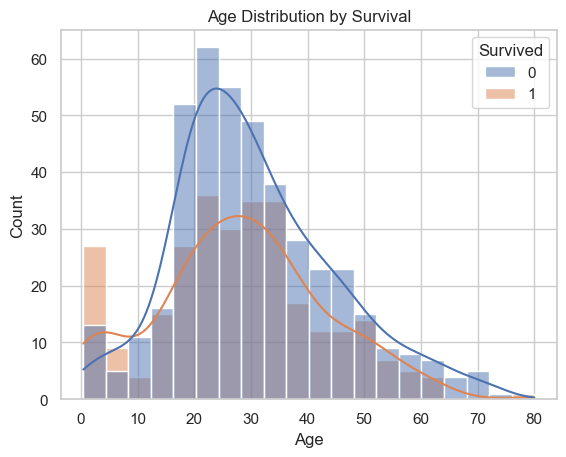

In [9]:
# Survival by Age 
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True)
plt.title('Age Distribution by Survival')
plt.show()

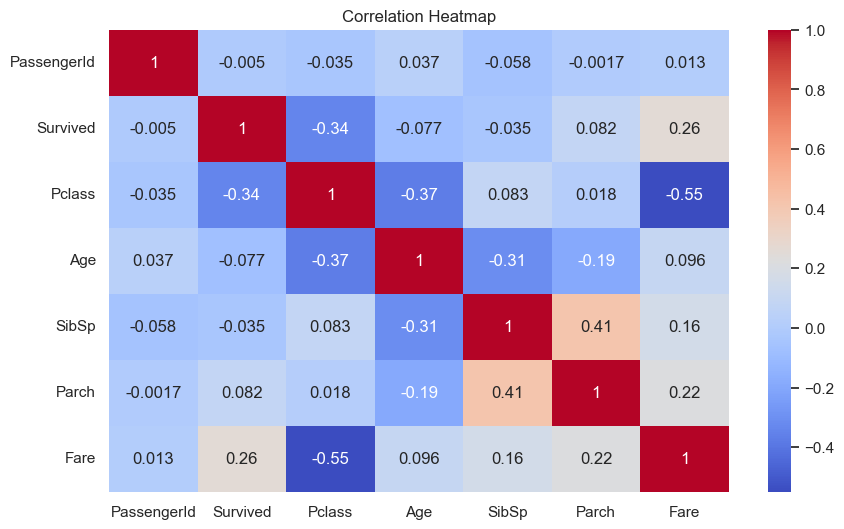

In [10]:
# Correlation Heatmap 
plt.figure(figsize=(10,6))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**<span style="color:#306998;">Key Insights from EDA</span>**

* Females had significantly higher survival rates than males
* First_class passangers were more likely to survive
* Age shows some influence, particularly for children
* Several features contain missing values and will require preprocessing 

**<span style="color:#00B894;">Data Cleaning and Feature Engineering</span>**

In this section we handle missing values, prepare features for modeling, and create new variables that may improve model performance. 

In [11]:
# Identify missing values 

train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
# Do not drop Cabin yet because we need it to create Deck later
# We will drop Ticket and Cabin after feature engineering

In [13]:
# Handle missing values 

# Age (numerical)
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
test_df['Age'].fillna(test_df['Age'].median(), inplace=True)

# Embarked (categorical)
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)
test_df['Embarked'].fillna(test_df['Embarked'].mode()[0], inplace=True)

# Fare (only missing in test)
test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)

C:\Users\alyss\AppData\Local\Temp\ipykernel_13256\1415289644.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
C:\Users\alyss\AppData\Local\Temp\ipykernel_13256\1415289644.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [14]:
# Feature Engineering 

# Family size 
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] +1
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] +1 

# Is Alone 
train_df['IsAlone'] = (train_df['FamilySize'] ==1).astype(int)
test_df['IsAlone'] = (test_df['FamilySize'] ==1).astype(int)

# Extract title from Name 
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
test_df['Title'] = test_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Group rare titles 
rare_titles =['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
train_df['Title']= train_df['Title'].replace(rare_titles, 'Rare')
test_df['Title']= test_df['Title'].replace(rare_titles, 'Rare')

train_df['Title']= train_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
train_df['Title']= train_df['Title'].replace('Mme', 'Mrs')

test_df['Title']= test_df['Title'].replace(['Mlle', 'Ms'], 'Miss')
test_df['Title']= test_df['Title'].replace('Mme', 'Mrs')

# Fare per person (used in previous model that was not as successful) 
train_df['FarePerPerson'] = train_df['Fare'] / train_df['FamilySize']
test_df['FarePerPerson'] = test_df['Fare'] / test_df['FamilySize']

train_df['Sex_Pclass'] = train_df['Sex'] + "_" + train_df['Pclass'].astype(str)
test_df['Sex_Pclass'] = test_df['Sex'] + "_" + test_df['Pclass'].astype(str)

In [15]:
# Drop unnecessary columns 
test_ids = test_df['PassengerId']

train_df = train_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
test_df = test_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

In [16]:
# Quick check of data 

train_df.head()
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Survived       891 non-null    int64  
 1   Pclass         891 non-null    int64  
 2   Sex            891 non-null    object 
 3   Age            891 non-null    float64
 4   SibSp          891 non-null    int64  
 5   Parch          891 non-null    int64  
 6   Fare           891 non-null    float64
 7   Embarked       891 non-null    object 
 8   FamilySize     891 non-null    int64  
 9   IsAlone        891 non-null    int64  
 10  Title          891 non-null    object 
 11  FarePerPerson  891 non-null    float64
 12  Sex_Pclass     891 non-null    object 
dtypes: float64(3), int64(6), object(4)
memory usage: 90.6+ KB


**<span style="color:#306998;">Feature Engineering Summary</span>**

* Created "FamilySize" and "IsAlone" to capture social structure
* Extracted "Title" from passenger names to represent social status
* Handled missing values using median and mode imputation
* Removed irrelevant or sparse features such as Cabin and Ticket 

**<span style="color:#00B894;">Modeling</span>**

In this section, we build machine learning models using pipelines to ensure consistent preprocessing. We compare multiple models and evaluate their performance using a validation split. 

In [17]:
# Seperate features and target 

X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

In [18]:
# Create train/test split (already imported sklearn functions)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
# Identify feature types 
numeric_features =['Age', 'Fare', 'FamilySize', 'FarePerPerson', 'SibSp', 'Parch']
categorical_features = ['Sex', 'Embarked', 'Pclass', 'Title', 'IsAlone', 'Sex_Pclass']

In [20]:
# Build preprocessing pipelines 
# Numeric 
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

# Categorical 
categorical_pipeline= Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

In [21]:
# Combine with columntransformer 
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features), 
    ('cat', categorical_pipeline, categorical_features)
])

In [22]:
# Building Models 

# Logistic Regression (baseline)
log_model = Pipeline([
    ('preprocessor', preprocessor), 
    ('classifier', LogisticRegression(max_iter=1000))
])

In [23]:
# Random Forest (stronger model)
rf_model= Pipeline([
    ('preprocessor', preprocessor), 
    ('classifier', RandomForestClassifier(random_state=42))
])

# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline([
    ('preprocessor', preprocessor), 
    ('classifier', GradientBoostingClassifier(
        n_estimators=300, 
        learning_rate=0.05, 
        max_depth=3, 
        random_state=42
    ))
])


In [24]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score 

def run_experiment(model, X, y, X_train, X_val, y_train, y_val, name):
    # cross-validation 
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()

    # Fit on training split 
    model.fit(X_train, y_train)

    # Validation accuracy 
    preds= model.predict(X_val)
    val_acc = accuracy_score(y_val, preds)

    return {
        "Model": name, 
        "CV Score": round(cv_mean, 4), 
        "Validation Score": round(val_acc, 4)
    }

In [25]:
results = []

results.append(run_experiment(log_model, X, y, X_train, X_val, y_train, y_val, "Logistic Regression"))
results.append(run_experiment(rf_model, X, y, X_train, X_val, y_train, y_val, "Random Forest"))
results.append(run_experiment(gb_model, X, y, X_train, X_val, y_train, y_val, "Gradient Boosting"))

In [26]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="CV Score", ascending=False)
results_df

,Model,CV Score,Validation Score
2,Gradient Boosting,0.8429,0.8324
0,Logistic Regression,0.8249,0.8212
1,Random Forest,0.8059,0.8436


In [27]:
# Old Evaluation approach (replaced by experiment table)

#Cross Validation 
#for name, model in {
    #"Logistic Regression": log_model,
    #"Random Forest": rf_model,
    #"Gradient Boosting": gb_model
#}.items():
    
    #scores = cross_val_score(model, X, y, cv=5)
    #print(f"{name}: {scores.mean():.4f}")

In [28]:
# Train the models

#log_model.fit(X_train, y_train)
#rf_model.fit(X_train, y_train)
#gb_model.fit(X_train, y_train)

In [29]:
# Make predictions 

#log_preds = log_model.predict(X_val)
#rf_preds = rf_model.predict(X_val)
#gb_preds = gb_model.predict(X_val)

In [30]:
# Evaluate models (sklearn imports already done)

#log_acc = accuracy_score(y_val, log_preds)
#rf_acc = accuracy_score(y_val, rf_preds)
#gb_acc = accuracy_score(y_val, gb_preds)

#print("Logistic Regression Accuracy:", log_acc)
#print("Random Forest Accuracy:", rf_acc)
#print("Gradient Boosting Accuracy:", gb_acc)

In [31]:
# Classification Report 

#print("logistic Regression Report:\n", classification_report(y_val, log_preds))
#print("Random Forest Report:\n", classification_report(y_val, rf_preds))
#print("Gradient Boosting Report:\n", classification_report(y_val, gb_preds))

In [33]:
# Choose the best model 

#model_scores = {
    #'log_model': log_acc, 
    #'rf_model': rf_acc, 
    #'gb_model': gb_acc,
#}

#best_model = max(
    #[(log_model, log_acc), (rf_model, rf_acc), (gb_model, gb_acc),], key=lambda x: x[1]
#)[0]

**<span style="color:#306998;">Model Evaluation</span>**

* Originally I ran this in a traditional train, predict, accuracy comparison model
* This wasn't proving as fruitful as I wanted, so replaced this with an "Experiment" section to replace the old cross-validation loop, implement a function, and let the table drive decisions. 
* Logistic Regression provides a solide baseline model
* Random Forest performs better by capturing non-linear relationships
* Pipelines ensure preprocessing is applied consistently across training and validation data
* For the final model I will be using Gradient Boosting becuase it has the best CV score by a clear margin. It is the strongest, most consistent model across folds
* Random Forest does have the best single validation schore, but its CV is much lower, likely due to overfitting to that one split. 

**<span style="color:#00B894;">Final Model and Kaggle Submission</span>**

after comparing model performance on a validation split, the best_performing model is retained on the full training dataset. Predictions are then generated for the Kaggle test set and saved in the required submission format. This current format and set up recieved a kaggle score of .756. 

In [34]:
# Retrain the best model on all labeled data 
best_model = gb_model
best_model.fit(X,y)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
# Make predicstions on the kaggle test set 
test_predictions = best_model.predict(test_df)

In [36]:
# Build the submission file 
submission = pd.DataFrame({
    'PassengerID': test_ids, 
    'Survived': test_predictions
})

submission.head()

,PassengerID,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [37]:
# Save CSV 
submission.to_csv('submission.csv', index=False)
print("submission.csv has been created.")

submission.csv has been created.


In [38]:
submission.to_csv("C:/Users/alyss/OneDrive/Desktop/submission.csv", index=False)